# Supervised Probabilistic PCA (SPPCA) with ARD for AML / ALL / Normal Classification


## Table of Contents

1. [Introduction](#introduction)  
2. [Data Loading & Preprocessing](#data-loading-preprocessing)  
4. [Model Definition: PPCA with ARD](#model-definition-ppca-with-ard)  
5. [Inference Setup](#inference-setup)  
6. [Model Training](#model-training)  
7. [Evaluation & Classification](#evaluation-classification)  
8. [Results & Visualization](#results-visualization)  
9. [Conclusion & Future Work](#conclusion-future-work)  


**Data**: Extracted from https://portal.gdc.cancer.gov/analysis_page?app=CohortBuilder&tab=general, loaded in to chunks of 70% train, 15% validation, 15% test using our custom Chunkloader.py script, and stored as three csv files.


**Preprocessing**: Using the function `load_and_preprocess()` data is loaded and preprocessed dropping non-numeric gene-expression values. Additional Z-score normalization and clipping of outliers is applied to the data.

**Modelling**: A Supervised Probabilistic PCA (SPPCA) model is defined to learn a latent space `z`. The size of the latent space is regulated by Automatic Relevance Detection (ARD). Besides dimensionality reduction of the data into latent space, the model is extended with labeled data thus making the model supervised and allowing for classification of the data into AML, ALL, and Normal classes.

**Classification**: General classification parameters `A` and `b` are inferred from the training data under supervision, while a new latent space `z` is inferred unsupervised from the relevant data one whishes to classify. Classification is performed using `Argmax` on the logits `A @ z + b`.

**Feature Importance (gene importance)**: A feature importance module is used to rank the genes based on their contribution to reduce the observed space to the latent space through `W`, as well as the contribution of each gene to the classification task through `A`. From this, the top genes are selected for with possible further analysis.

**Execution**: The notebook is designed to be run using the large dataset of 5.787 subjects each with 60.660 gene expressions. This is executed on a High Performance Computing (HPC) server hosted by DTU Computing Center. The code is run through a BASH job script located on Thinlinc.






In [ ]:
# IMPORTS
import time

import pandas as pd
import numpy as np
import os

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam, Adam

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

from featureimportance import compute_feature_importance_from_AW,plot_top_genes_from_AW,plot_all_genes_from_AW

# EXTERNAL VALUES FROM BASH SCRIPT
Toggle = os.environ.get("toggle", "small")  # Default to "small"
SVI_PPCA_n_steps = int(os.environ.get("SVI_PPCA_n_steps", 1000))  # Default to 1000
SVI_z_n_steps = int(os.environ.get("SVI_z_n_steps", 1000))  # Default to 1000
latent_dim = int(os.environ.get("latent_dim", 100))  # Default to 100


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


<a id="introduction"></a>
## 1. Introduction

Understanding genetic profiles is crucial in cancer research because mutations and gene expression changes drive the development, progression, and response to treatment of the disease. By analyzing genetic data, we can identify biomarkers and cancer subtypes, and ideally classify cancer based on samples of gene expressions.

This notebook implements a Supervised Probabilistic PCA (SPPCA) model with Automatic Relevance Detection (ARD) for the classification of Acute Myeloid Leukemia (AML), Acute Lymphoblastic Leukemia (ALL), and Normal samples based on gene expression data. Additionally, the learned latent space will be used to identify genes that show the most significant contribution to the classification task, providing insights into the underlying biological processes.

We have chosen to use PPCA as the core of our model primarily due to its capacity to reduce the dimensionality of the observed data to a much smaller, informative latent space. Gene expression datasets often contain thousands of genes (features) measured across relatively few samples, leading to the well-known "curse of dimensionality." This high dimensionality not only increases computational burden, but can also obscure meaningful patterns due to noise and redundancy in the data.


<a id="data-loading-preprocessing"></a>
## 2. Loading & Preprocessing Data

A toggle button has been utilized to swap between a smaller debugging dataset and the full dataset.

Debugging dataset consist of two dataset each with 200 subjects with 400 gene expressions.
Full dataset consists of three dataset one for training (4050, 60660), one for validation (869, 60660), and one for testing (868, 60660).

Normalization is applied to the data using Z-score normalization, and outliers are clipped to better fit with model assumptions (observations are assumed to be Gaussian distributed).


In [ ]:
def load_small_data():
    pyro.set_rng_seed(42)

    # Load small dataset
    test_data_path = "small_test_data.csv"
    test_label_path = "small_test_labels.csv"
    test_data = pd.read_csv(test_data_path).values.astype(np.float32)
    test_label = pd.read_csv(test_label_path).values.flatten()

    val_data_path = "small_val_data.csv"
    val_label_path = "small_val_labels.csv"
    val_data = pd.read_csv(val_data_path).values.astype(np.float32)
    val_label = pd.read_csv(val_label_path).values.flatten()

    genes_path = "gene_label.csv"
    gene_names = pd.read_csv(genes_path, header=None).values[:400,0]
    gene_type = pd.read_csv(genes_path, header=None).values[:400,1]

    return test_data, test_label, val_data, val_label, gene_names, gene_type



def load_large_data():
    pyro.set_rng_seed(42)
    torch.set_num_threads(8)

    # File paths
    train_path = "/work3/s214806/working_chunk_train.csv"
    val_path = "/work3/s214806/working_chunk_val.csv"
    test_path = "/work3/s214806/working_chunk_test.csv"

    LABEL_MAPPING = {'AML': 0, 'ALL': 1, 'Normal': 2}



    # Load and preprocess data
    def load_and_preprocess(path, data_type):
        df = pd.read_csv(path, index_col=0, low_memory=False).T
        df_shape_before = df.shape[1]

        labels = df['Cancer'].map(LABEL_MAPPING).dropna()

        gene_expressions = df.drop(['Cancer', 'Preservation Method', 'Tissue Type', 'Tumor Descriptor', 'Specimen Type'], 
                                axis=1, errors='ignore')

        gene_expressions = gene_expressions.apply(pd.to_numeric, errors='coerce')
        gene_expressions = gene_expressions.dropna(axis=1)

        df_shape_after = gene_expressions.shape[1]
        print(f"{data_type} features (genes expressions) BEFORE ({df_shape_before}) and AFTER ({df_shape_after}) removing non-numeric columns")

        gene_expressions = gene_expressions.astype(np.float32)
        return gene_expressions.values, labels.loc[gene_expressions.index].values
    



    # Load your data using your function
    X_train, y_train = load_and_preprocess(train_path, "Train data")
    X_val, y_val = load_and_preprocess(val_path, "Validation data")
    X_test, y_test = load_and_preprocess(test_path, "Test data")

    print("X_train shape:", X_train.shape)
    print("y_train shape:", y_train.shape)

    print("X_val shape:", X_val.shape)
    print("y_val shape:", y_val.shape)

    print("X_test shape:", X_test.shape)
    print("y_test shape:", y_test.shape)

    genes_path = "gene_label.csv"
    gene_names = pd.read_csv(genes_path, header=None).values[:,0]
    gene_type = pd.read_csv(genes_path, header=None).values[:,1]

    return X_train, y_train, X_val, y_val, X_test, y_test, gene_names, gene_type




if Toggle == "small":
    X_train, y_train, X_val, y_val, gene_names, _ = load_small_data()
elif Toggle == "large":
    X_train, y_train, X_val, y_val, X_test, y_test, gene_names, _ = load_large_data()


In [3]:
def normalize_data(data):
    # Z-score normalization per gene
    X_train_mean = data.mean(axis=0)
    X_train_std = data.std(axis=0) + 1e-6  # avoid div-by-zero
    X_norm = (data - X_train_mean) / X_train_std
    X_clipped = np.clip(X_norm, -10, 10)
    return X_clipped, X_train_mean, X_train_std

X_log = np.log1p(X_train)
X_norm, X_train_mean, X_train_std = normalize_data(X_log)

In [ ]:
def present_data(data, label, norm_data):
    print("Data shape:", data.shape)
    print("Label shape:", label.shape)
    print(f"AML", np.sum(label == 0), "ALL", np.sum(label == 1), "Normal", np.sum(label == 2))

    # Flatten the matrix (5000 subjects × 60,000 genes) into a 1D array
    raw_flat_gene_expr = data.flatten()
    norm_flat_gene_expr = norm_data.flatten()

    # Plot distributions in two subplots
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(raw_flat_gene_expr, bins=100, color='steelblue', alpha=0.7)
    plt.title("Raw Gene Expression Values")
    plt.xlabel("Raw Expression Level Values")
    plt.ylabel("Frequency")
    plt.grid()
    plt.yscale('log')  # Optional: log scale helps if values span wide range
    plt.subplot(1, 2, 2)
    plt.hist(norm_flat_gene_expr, bins=100, color='orange', alpha=0.7)
    plt.title("Z-score Normalized Gene Expression Values")
    plt.xlabel("Z-score Normalized Expression Level Values")
    plt.ylabel("Frequency")
    plt.grid()
    plt.yscale('log')  # Optional: log scale helps if values span wide range
    plt.tight_layout()
    plt.show()



present_data(X_train, y_train, X_norm)


<!-- Anchor for Environment Setup -->
<a id="model-definition-ppca-with-ard"></a>
## 3. Model definition of PPCA with ARD



In [4]:
def supervised_ppca_model_ard(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape


    a0, b0 = torch.tensor(1e-1), torch.tensor(1e-1)
    alpha = pyro.sample("alpha", dist.Gamma(a0.expand(latent_dim), b0.expand(latent_dim)).to_event(1))

    # (2) Loading matrix W with ARD prior (each latent factor scaled by α)
    # W_qd ~ N(0, 1/α_q) ⇒ W ~ N(0, diag(1/α)) component-wise
    W = pyro.sample("W", dist.Normal(torch.zeros(latent_dim, n_genes), alpha.unsqueeze(-1).rsqrt()).to_event(2))

    # (3) Bayesian logistic regression parameters for classification head
    # A_kq ~ N(0,1), b_k ~ N(0,1) for class weights and bias
    A = pyro.sample("A", dist.Normal(0., 1.).expand([n_classes, latent_dim]).to_event(2))
    b = pyro.sample("b", dist.Normal(0., 1.).expand([n_classes]).to_event(1))

    # (4) Per-gene observation noise σ (model parameter)
    # σ_d is fixed and positive; used in X ~ N(z @ W, σ)
    sigma = pyro.param("sigma_loc", torch.full((n_genes,), 0.1), constraint=dist.constraints.positive)

    # (5) Generative process for each data sample
    with pyro.plate("data", n_samples):
        # Latent representation z per sample
        # z_n ~ N(0, diag(1/α)) for each sample n
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))
    
        # Reconstruction of gene expression (observed data X)
        # x_n ~ N(W^T z_n, σ) where σ is a fixed noise vector
        x_loc = torch.matmul(z, W)
        pyro.sample("obs", dist.Normal(x_loc, sigma).to_event(1), obs=X)

        # Classification logits (linear model from latent variables)
        # logits_n = A z_n + b ⇒ y_n ~ Categorical(softmax(logits_n))
        logits = torch.matmul(z, A.T) + b
        pyro.sample("y", dist.Categorical(logits=logits), obs=y)


def supervised_ppca_guide_ard(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape


    alpha_a = pyro.param("alpha_a", torch.ones(latent_dim), constraint=dist.constraints.positive)
    alpha_b = pyro.param("alpha_b", torch.ones(latent_dim), constraint=dist.constraints.positive)
    alpha = pyro.sample("alpha", dist.Gamma(alpha_a, alpha_b).to_event(1))

    # (2) Variational posterior over loading matrix W
    # q(W_qd) = N(w_loc_qd, (w_scale_qd / sqrt(α_q))^2)
    w_loc = pyro.param("w_loc", torch.randn(latent_dim, n_genes))
    w_scale = pyro.param("w_scale", torch.ones(latent_dim, n_genes), constraint=dist.constraints.positive)
    pyro.sample("W", dist.Normal(w_loc, w_scale / alpha.unsqueeze(-1).sqrt()).to_event(2))

    # (3) Variational posterior over classification parameters A and bias b
    # q(A_kq) = N(A_loc_kq, A_scale_kq^2), q(b_k) = N(b_loc_k, b_scale_k^2)
    A_loc = pyro.param("A_loc", torch.randn(n_classes, latent_dim))
    A_scale = pyro.param("A_scale", torch.ones(n_classes, latent_dim), constraint=dist.constraints.positive)
    pyro.sample("A", dist.Normal(A_loc, A_scale).to_event(2))

    b_loc = pyro.param("b_loc", torch.zeros(n_classes))
    b_scale = pyro.param("b_scale", torch.ones(n_classes), constraint=dist.constraints.positive)
    pyro.sample("b", dist.Normal(b_loc, b_scale).to_event(1))

    # (4) Variational posterior for latent variables z
    # q(z_nq) = N(z_loc_nq, (z_scale_nq / sqrt(α_q))^2)
    z_loc = pyro.param("z_loc", torch.randn(n_samples, latent_dim))
    z_scale = pyro.param("z_scale", torch.ones(n_samples, latent_dim), constraint=dist.constraints.positive)

    with pyro.plate("data", n_samples):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))


In [5]:
latent_dim = 100
n_classes = 3

X_train_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

In [6]:
pyro.clear_param_store()

optimizer = ClippedAdam({"lr": 0.05})
svi = SVI(supervised_ppca_model_ard, supervised_ppca_guide_ard, optimizer, loss=Trace_ELBO())

start_time = time.time()

n_steps = SVI_PPCA_n_steps
for step in range(n_steps):
    loss = svi.step(X_train_tensor, y_train_tensor, latent_dim, n_classes)
    if step % 20 == 0:
        print(f"[Step {step}] Loss: {loss:.2f}")

# Total time spent
print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")

[Step 0] Loss: 4728034827.89
[Step 20] Loss: 21614016.68
[Step 40] Loss: 289076.75
[Step 60] Loss: 145917.95
[Step 80] Loss: 128097.87
[Step 100] Loss: 123785.47
[Step 120] Loss: 121978.15
[Step 140] Loss: 121658.60
[Step 160] Loss: 120260.01
[Step 180] Loss: 118365.74
[Step 200] Loss: 117458.96
[Step 220] Loss: 116048.60
[Step 240] Loss: 114581.32
[Step 260] Loss: 113217.05
[Step 280] Loss: 112243.77
[Step 300] Loss: 111453.24
[Step 320] Loss: 111165.39
[Step 340] Loss: 110262.76
[Step 360] Loss: 110349.20
[Step 380] Loss: 109822.35
[Step 400] Loss: 109818.47
[Step 420] Loss: 109865.92
[Step 440] Loss: 109981.89
[Step 460] Loss: 109148.00
[Step 480] Loss: 109734.63
[Step 500] Loss: 109227.03
[Step 520] Loss: 109408.39
[Step 540] Loss: 109678.77
[Step 560] Loss: 109888.02
[Step 580] Loss: 108846.78
[Step 600] Loss: 109192.01
[Step 620] Loss: 108615.57
[Step 640] Loss: 108564.80
[Step 660] Loss: 109826.30
[Step 680] Loss: 108988.68
[Step 700] Loss: 110270.44
[Step 720] Loss: 110216.66
[

In [7]:
print(list(pyro.get_param_store().keys()))

['alpha_a', 'alpha_b', 'w_loc', 'w_scale', 'A_loc', 'A_scale', 'b_loc', 'b_scale', 'z_loc', 'z_scale', 'sigma_loc']


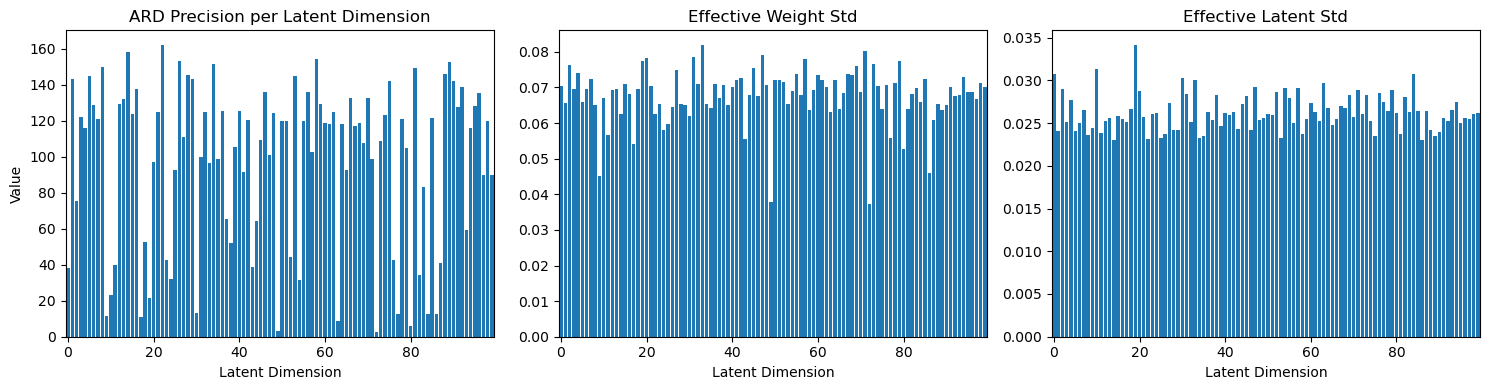

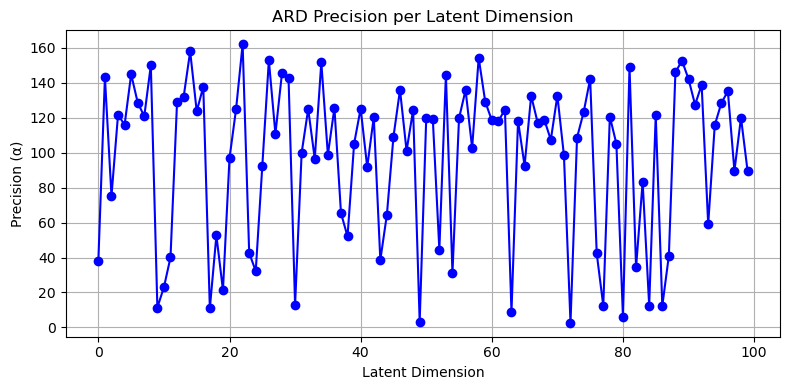

In [8]:
#1) Pull in and compute your ARD precision means
alpha_a = pyro.param("alpha_a").detach().cpu().numpy()
alpha_b = pyro.param("alpha_b").detach().cpu().numpy()
alpha_mean = alpha_a / alpha_b
latent_dim = alpha_mean.shape[0]

# 2) Effective W std (average over genes)
w_scale    = pyro.param("w_scale").detach().cpu().numpy()
w_eff_mean = (w_scale / np.sqrt(alpha_mean[:, None])).mean(axis=1)

# 3) Effective z std (average over samples)
z_scale    = pyro.param("z_scale").detach().cpu().numpy()
z_eff_mean = (z_scale / np.sqrt(alpha_mean)).mean(axis=0)

# 4) Now plot—all variables are defined
x     = np.arange(latent_dim)
width = 0.8  # data‐unit width

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

axes[0].bar(x, alpha_mean,   width=width, align="center")
axes[0].set(title="ARD Precision per Latent Dimension", ylabel="Value")

axes[1].bar(x, w_eff_mean,   width=width, align="center")
axes[1].set(title="Effective Weight Std")

axes[2].bar(x, z_eff_mean,   width=width, align="center")
axes[2].set(title="Effective Latent Std")

for ax in axes:
    ax.set_xlabel("Latent Dimension")
    ax.set_xlim(-0.5, latent_dim - 0.5)

plt.tight_layout()
plt.show()

# plot of alpha_mean
plt.figure(figsize=(8, 4))
plt.plot(alpha_mean, marker='o', linestyle='-', color='b')
plt.title("ARD Precision per Latent Dimension")
plt.xlabel("Latent Dimension")
plt.ylabel("Precision (α)")
plt.grid()
plt.tight_layout()
plt.show()

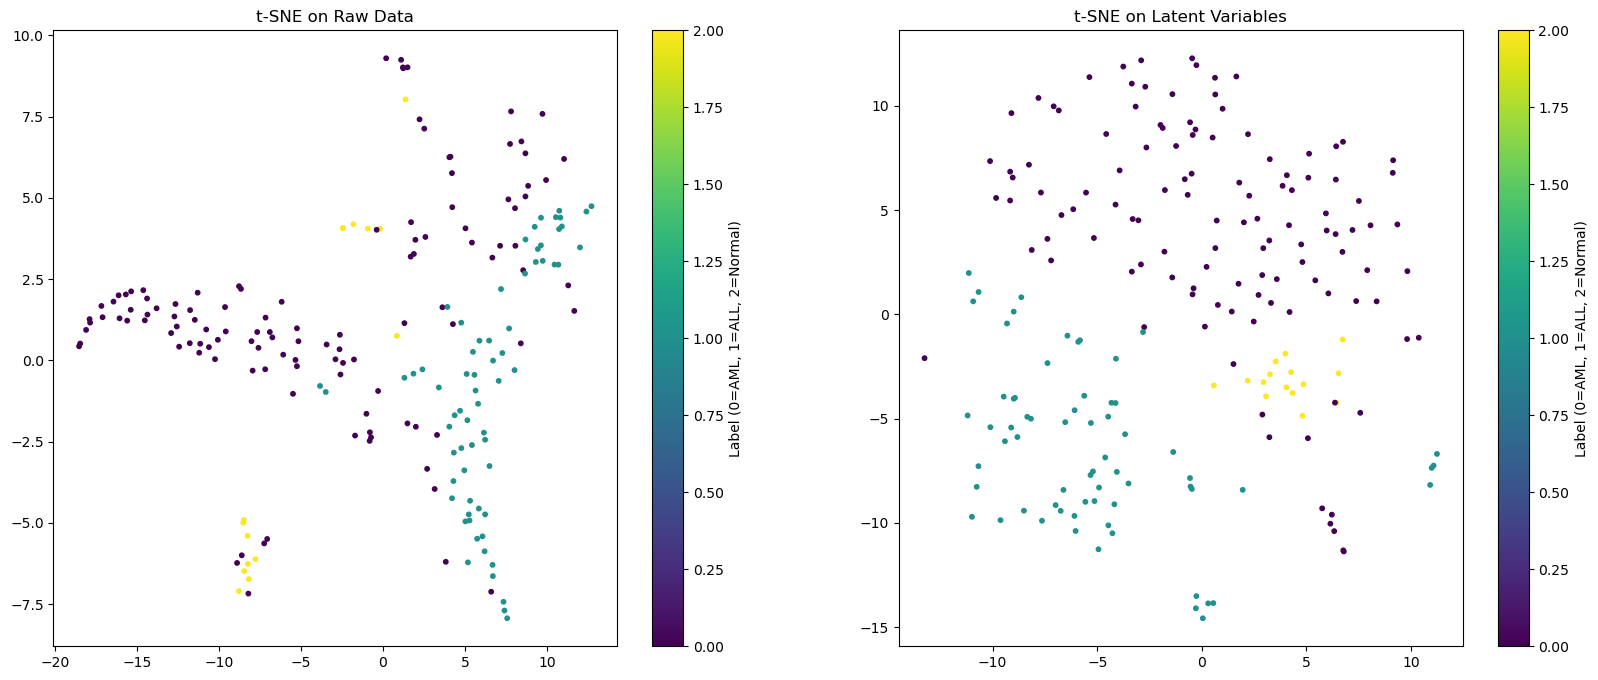

In [9]:
def TSNE_plots(z_loc, labels):
    raw_data_tsne = TSNE(n_components=2).fit_transform(X_train)
    z_post_tsne = TSNE(n_components=2).fit_transform(z_loc.detach().cpu().numpy())

    plt.figure(figsize=(20, 8))
    plt.subplot(1, 2, 1)
    plt.scatter(raw_data_tsne[:, 0], raw_data_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Raw Data")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.subplot(1, 2, 2)
    plt.scatter(z_post_tsne[:, 0], z_post_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Latent Variables")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.show()

z_loc = pyro.param("z_loc").detach()
TSNE_plots(z_loc, y_train)


In [10]:
X_val_norm = normalize_data(np.log1p(X_val))[0]
X_val_tensor = torch.tensor(X_val_norm, dtype=torch.float32)

In [11]:
# --- assume your training SVI has run and ps is populated ---
ps       = pyro.get_param_store()
W_pm     = ps["w_loc"].detach()                    # [latent_dim, n_genes]
sigma_pm = ps["sigma_loc"].detach()                # scalar or [n_genes]
A_pm     = ps["A_loc"].detach()                    # [n_classes, latent_dim]
b_pm     = ps["b_loc"].detach()                    # [n_classes]

# TEST

In [12]:
# --- 1) Unsupervised PPCA “model” that only generates X under locked params ---
def infer_z_model(X):
    N = X.shape[0]

    with pyro.plate("data", N):
        # ARD‐scaled prior on z
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))
        # likelihood for X under fixed W, sigma
        x_loc = torch.matmul(z, W_pm)                     # [N_val, n_genes]
        pyro.sample("x", dist.Normal(x_loc, sigma_pm).to_event(1), obs=X)

# --- 2) Guide that only learns z_loc_val / z_scale_val ---
def infer_z_guide(X):
    N = X.shape[0]

    z_loc   = pyro.param("z_loc_test", torch.randn(N, latent_dim))
    z_scale = pyro.param("z_scale_test", torch.ones(N, latent_dim), constraint=dist.constraints.positive)
    with pyro.plate("data", N):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))

# --- 3) Run SVI on X only to infer z_loc_val / z_scale_val ---
# (do NOT clear the ParamStore here if you want to keep W_pm etc.)
optimizer_inf = ClippedAdam({"lr": 0.05})
svi_inf       = SVI(infer_z_model, infer_z_guide, optimizer_inf, loss=Trace_ELBO())

start = time.time()
n_steps = SVI_z_n_steps
for step in range(n_steps):
    loss = svi_inf.step(X_val_tensor)
    if step % 20 == 0:
        print(f"[val step {step}] loss = {loss:.1f}")


print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")


[val step 0] loss = 728580.6
[val step 20] loss = 304501.0
[val step 40] loss = 148720.0
[val step 60] loss = 101423.8
[val step 80] loss = 84621.0
[val step 100] loss = 80996.5
[val step 120] loss = 79598.9
[val step 140] loss = 79585.0
[val step 160] loss = 79498.1
[val step 180] loss = 79400.5
[val step 200] loss = 79377.0
[val step 220] loss = 79560.7
[val step 240] loss = 79462.4
[val step 260] loss = 79406.7
[val step 280] loss = 79494.7
[val step 300] loss = 79436.7
[val step 320] loss = 79443.7
[val step 340] loss = 79595.2
[val step 360] loss = 79690.0
[val step 380] loss = 79545.5
[val step 400] loss = 79497.5
[val step 420] loss = 79713.1
[val step 440] loss = 79527.2
[val step 460] loss = 79578.1
[val step 480] loss = 79603.9
[val step 500] loss = 79600.4
[val step 520] loss = 79599.2
[val step 540] loss = 79540.1
[val step 560] loss = 79570.0
[val step 580] loss = 79791.8
[val step 600] loss = 79616.5
[val step 620] loss = 79669.0
[val step 640] loss = 79559.8
[val step 66

Validation Accuracy: 0.9700


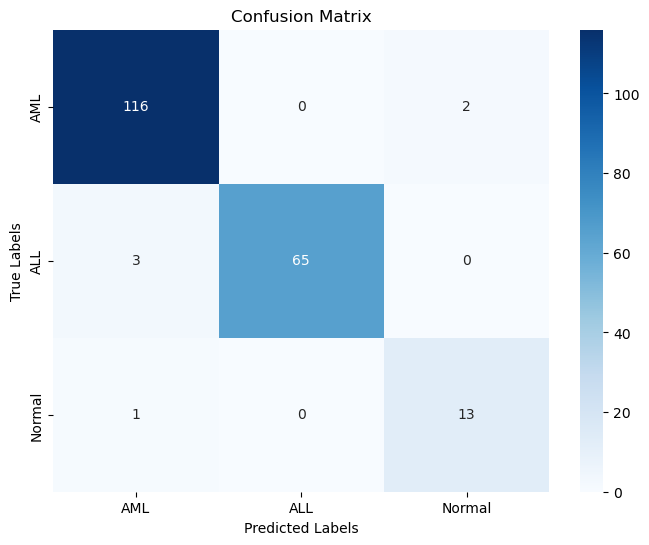

In [ ]:
# --- 4) Extract your inferred latent means ---
z_loc_test = pyro.param("z_loc_test").detach()   # [n_val_samples, latent_dim]

# --- 5) Prediction function ---
def predict_classes(z_loc, A, b, y_true):
    # Compute logits and probabilities
    logits = torch.matmul(z_loc, A.T) + b
    y_hat  = torch.argmax(logits, dim=-1).cpu().numpy()

    # Compute accuracy
    y_true = np.array(y_true)
    accuracy = (y_true == y_hat).mean()
    print(f"Validation Accuracy: {accuracy:.4f}")

    # Confusion matrix
    conf_matrix = confusion_matrix(y_true, y_hat)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["AML", "ALL", "Normal"],
        yticklabels=["AML", "ALL", "Normal"]
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

    return y_hat

# --- 6) Call prediction with correct params ---
y_hat_val = predict_classes(z_loc_test, A_pm, b_pm, y_val)


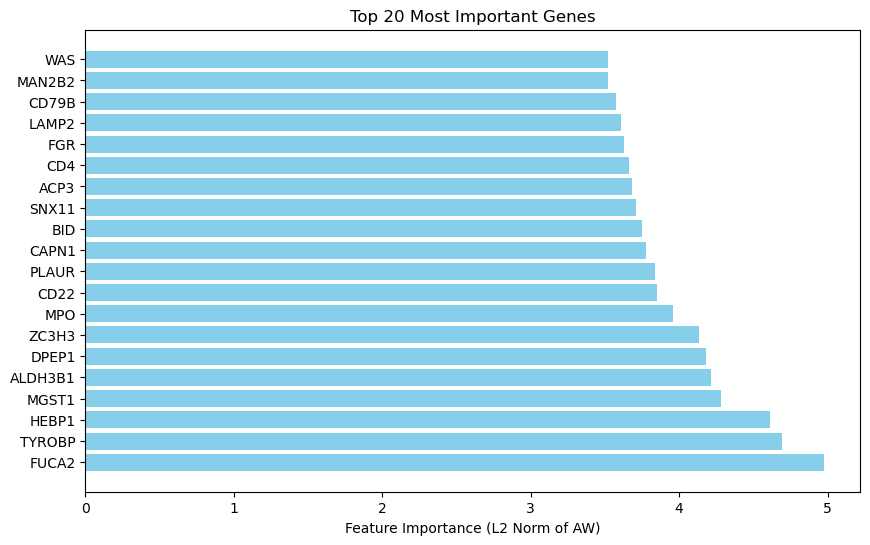

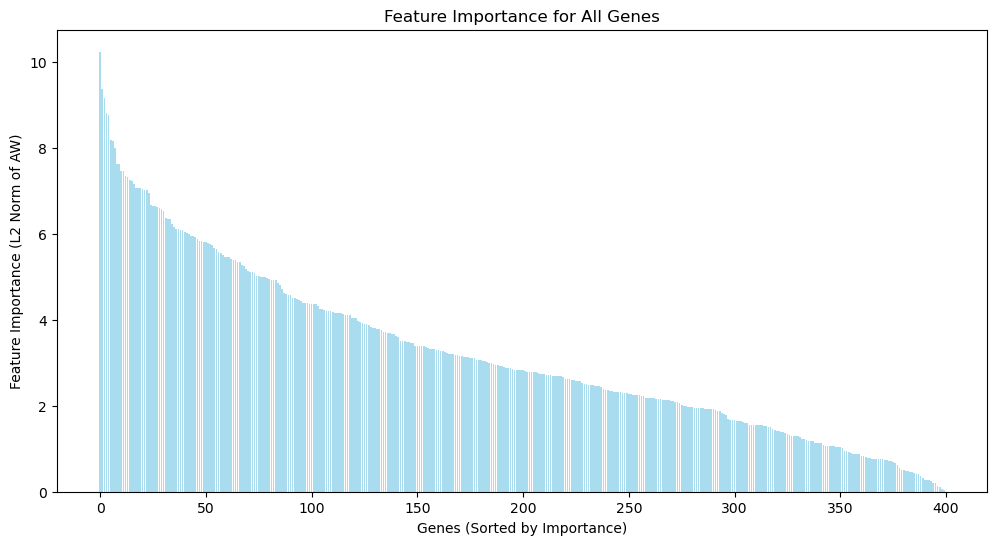

In [14]:
# Example usage
W = pyro.param("w_loc").detach().cpu().numpy()  # Shape: [latent_dim, n_genes]
A = A_pm.detach().cpu().numpy()                # Shape: [n_classes, latent_dim]
top_n = 20
gene_importance = np.linalg.norm(A @ W, axis=0)  # Compute importance for all genes


# Compute feature importance
top_indices, top_importance = compute_feature_importance_from_AW(W, A, alpha_mean, top_n=top_n)

# Plot the top genes
plot_top_genes_from_AW(top_indices, top_importance, top_n=top_n, gene_names=gene_names)
plot_all_genes_from_AW(gene_importance)

# VALIDATION

In [15]:
# --- 1) Unsupervised PPCA “model” that only generates X under locked params ---
def infer_z_val_model(X):
    N = X.shape[0]

    with pyro.plate("data", N):
        # ARD‐scaled prior on z
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))
        # likelihood for X under fixed W, sigma
        x_loc = torch.matmul(z, W_pm)                     # [N_val, n_genes]
        pyro.sample("x", dist.Normal(x_loc, sigma_pm).to_event(1), obs=X)

# --- 2) Guide that only learns z_loc_val / z_scale_val ---
def infer_z_val_guide(X):
    N = X.shape[0]

    z_loc   = pyro.param("z_loc_val", torch.randn(N, latent_dim))
    z_scale = pyro.param("z_scale_val", torch.ones(N, latent_dim), constraint=dist.constraints.positive)
    with pyro.plate("data", N):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))

# --- 3) Run SVI on X only to infer z_loc_val / z_scale_val ---
# (do NOT clear the ParamStore here if you want to keep W_pm etc.)
optimizer_inf = ClippedAdam({"lr": 0.05})
svi_inf       = SVI(infer_z_val_model, infer_z_val_guide, optimizer_inf, loss=Trace_ELBO())

start = time.time()
n_steps = SVI_z_n_steps
for step in range(n_steps):
    loss = svi_inf.step(X_val_tensor)
    if step % 20 == 0:
        print(f"[val step {step}] loss = {loss:.1f}")


print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")


[val step 0] loss = 714827.7
[val step 20] loss = 289013.0
[val step 40] loss = 161650.6
[val step 60] loss = 98996.4
[val step 80] loss = 84544.5
[val step 100] loss = 80959.7
[val step 120] loss = 79840.0
[val step 140] loss = 79707.1
[val step 160] loss = 79397.0
[val step 180] loss = 79390.7
[val step 200] loss = 79384.8
[val step 220] loss = 79422.1
[val step 240] loss = 79472.2
[val step 260] loss = 79359.8
[val step 280] loss = 79488.2
[val step 300] loss = 79504.8
[val step 320] loss = 79516.8
[val step 340] loss = 79560.0
[val step 360] loss = 79432.6
[val step 380] loss = 79614.7
[val step 400] loss = 79677.0
[val step 420] loss = 79547.3
[val step 440] loss = 79679.6
[val step 460] loss = 79633.6
[val step 480] loss = 79561.9
[val step 500] loss = 79620.5
[val step 520] loss = 79623.7
[val step 540] loss = 79696.8
[val step 560] loss = 79579.2
[val step 580] loss = 79552.1
[val step 600] loss = 79635.2
[val step 620] loss = 79689.9
[val step 640] loss = 79699.8
[val step 660

Validation Accuracy: 0.9600


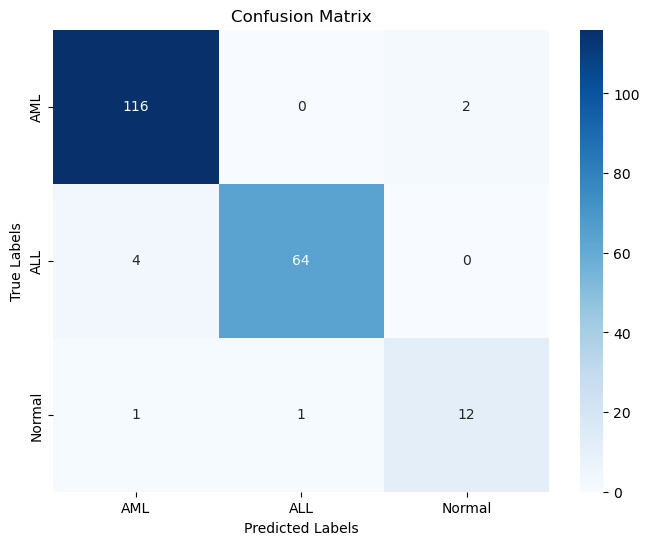

In [ ]:
# --- 4) Extract your inferred latent means ---
z_loc_val = pyro.param("z_loc_val").detach()   # [n_val_samples, latent_dim]

# --- 5) Prediction function ---
def predict_classes(z_loc, A, b, y_true):
    # Compute logits and probabilities
    logits = torch.matmul(z_loc, A.T) + b
    y_hat  = torch.argmax(logits, dim=-1).cpu().numpy()

    # Compute accuracy
    y_true = np.array(y_true)
    accuracy = (y_true == y_hat).mean()
    print(f"Validation Accuracy: {accuracy:.4f}")

    # Confusion matrix
    conf_matrix = confusion_matrix(y_true, y_hat)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["AML", "ALL", "Normal"],
        yticklabels=["AML", "ALL", "Normal"]
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

    return y_hat

# --- 6) Call prediction with correct params ---
y_hat_val = predict_classes(z_loc_val, A_pm, b_pm, y_val)


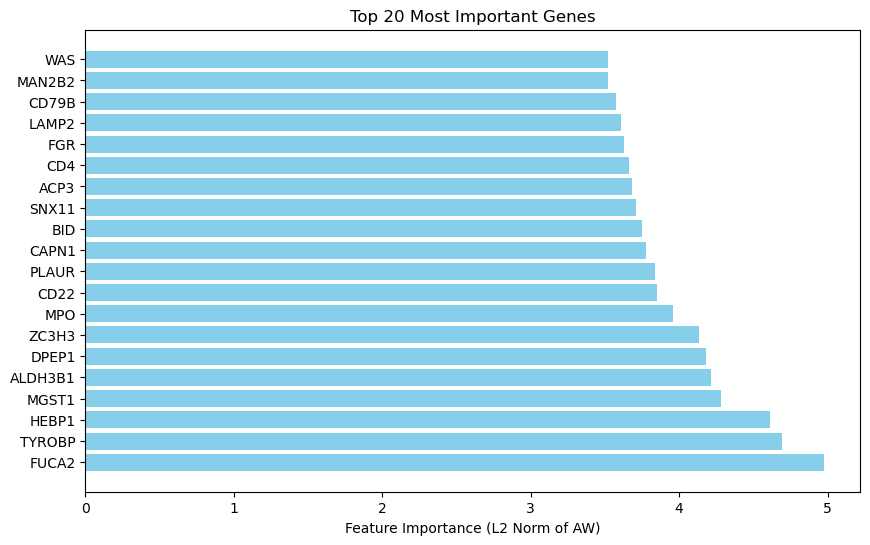

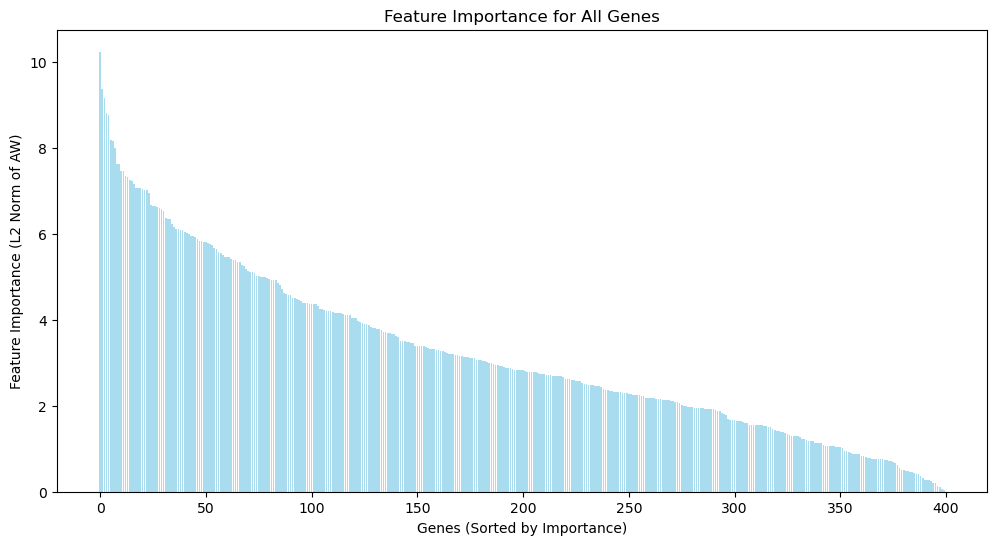

In [17]:
# Example usage
W = pyro.param("w_loc").detach().cpu().numpy()  # Shape: [latent_dim, n_genes]
A = A_pm.detach().cpu().numpy()                # Shape: [n_classes, latent_dim]
top_n = 20
gene_importance = np.linalg.norm(A @ W, axis=0)  # Compute importance for all genes


# Compute feature importance
top_indices, top_importance = compute_feature_importance_from_AW(W, A, alpha_mean, top_n=top_n)

# Plot the top genes
plot_top_genes_from_AW(top_indices, top_importance, top_n=top_n, gene_names=gene_names)
plot_all_genes_from_AW(gene_importance)